---
title: Computer Vision
jupyter: python3
---

## Introduction

Data science has a number of applications in computer vision. These have
increased in number and accuray in the past 5 years or so due to the
advancements in deep learning (both theory and computational feasibility). In
this topic, we shall experiment with some of the applications, utilising
existing deep learning models.

Here is a short list of applications of computer vision techniques:

1. Optical Character Recognition: Reading handwritten documents, car license
   plate numbers from images.  
2. Surveillance and traffic monitoring: Monitoring cars on a highway, tracking
   humans in security cameras for suspicious activity.
3. Machine inspection: Automatically detecting damage on components
   manufactured, such as silicon wafers, etc.

[Here](https://www.cs.ubc.ca/~lowe/vision.html) is an old page with a more
comprehensive list of applications.

In computer vision, the goal is to get a computer to perceive the world as *we*
see it. This is not easy even for us to do - we can get fooled by optical
illusions such as the ones below.

In general though, for us, it is possible to do things like pick out faces that
we recognise from a photograph of a crowd. But how can we get a computer to do
it? 

In [1]:
import cv2
import sys
import numpy as np
import os

import matplotlib.pyplot as plt
from IPython.display import YouTubeVideo, display, HTML, Image, Video

opencv_path = "opencv/samples/data/"
opencvxtra_path = "opencv_extra/testdata/dnn/"

## Image Processing

### Reading Images

The `opencv` package contains routines for reading images into Python. Images
are typically represented using the RGB colorspace. Each image is a (W x H x 3)
numpy array. Each layer corresponds to one of these channels. However, opencv
uses the order BGR. When you use `plt.imshow` to plot an image that has been
read in using opencv, take note of this, as it might not appear "correct".

In [2]:
#| fig-align: center
Image("data/starry_night.jpg", width=240)

from matplotlib import colormaps
#list(colormaps)

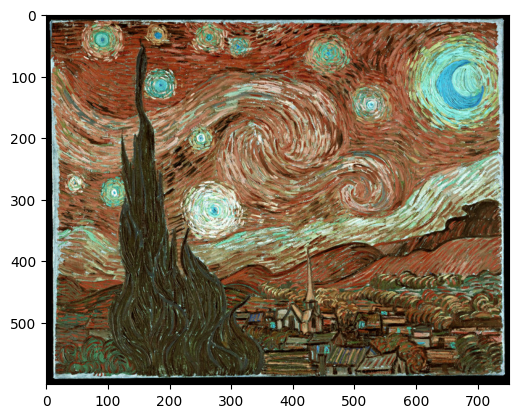

In [3]:
#| fig-align: center
starry_night = cv2.imread('data/starry_night.jpg')

# Reversed (not correct)
plt.imshow(starry_night);
#plt.imshow(starry_night[:, :, 0], cmap='Blues');

The following code should open up the starry night image in a new window on your
computer.

In [4]:
#| eval: false
# plotting with cv2.imshow returns the correct colours.
cv2.namedWindow('dst_rt', cv2.WINDOW_NORMAL)
cv2.resizeWindow('dst_rt', starry_night.shape[1], starry_night.shape[0])

# hit "q" to close window (do not hit the "X" button)
cv2.imshow('dst_rt', starry_night)
cv2.waitKey(0)
cv2.destroyAllWindows()

QFontDatabase: Cannot find font directory /home/viknesh/NUS/coursesTaught/ind5003-book/env/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/viknesh/NUS/coursesTaught/ind5003-book/env/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/viknesh/NUS/coursesTaught/ind5003-book/env/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/viknesh/NUS/coursesTaught/ind5003-book/env/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for ex

## Working with Masks

When working in a computer vision project, we often need to extract parts of
the image to work with, or to modify. This is typically done using masks. Masks
are black-and-white images that identify the foreground (white) and the
background (black).

Let us work with the following image of Lionel Messi, and see how we can use
masks and colour selection to outline the ball.

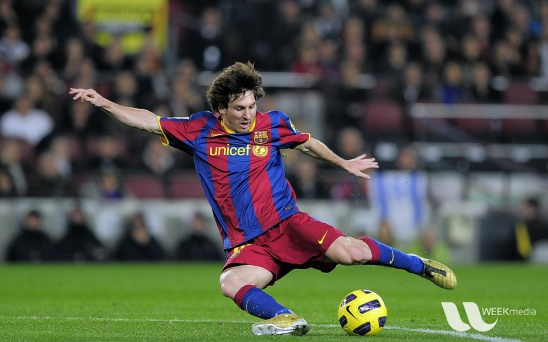

In [5]:
Image('data/messi5.jpg')

Our first task is to read the data into Python, and use a colour picker to
identify the colour of the ball. The following website provides a useful tool
for us to upload an image, and isolate the HSV (Hue-Saturation-Value)
representaion of the colour we wish to pick out:

<https://redketchup.io/color-picker>

Using this website, we learn that the RGB representation we want is
RGB=(244,251,95). We the convert this to HSV using a colour conversion
function.

In [6]:
messi = cv2.imread('data/messi5.jpg')
hsv = cv2.cvtColor(messi, cv2.COLOR_BGR2HSV)

In [7]:
# 244, 251, 95
cv2.cvtColor(np.uint8([[[95, 251, 244 ]]]), cv2.COLOR_BGR2HSV)

array([[[ 31, 158, 251]]], dtype=uint8)

In [8]:
# define range of yellow color in HSV 
lower_yellow = np.array([21,  100, 100])
upper_yellow = np.array([41, 255, 255])

In [9]:
# Threshold the HSV image to get only blue colors
mask1 = cv2.inRange(hsv, lower_yellow, upper_yellow)

Compare the black-and-white image below with the original one. The white
regions below correspond to yellow coloured sections in the original image. The
white pixels take the value 255, while the black pixels are 0. We are going to
modify the numpy array corresponding to this mask to correspond to only the
ball. 

*Take note of where the origin is: at the top-left corner. The x-values increase to the right from there; y-values increase downward from there.*

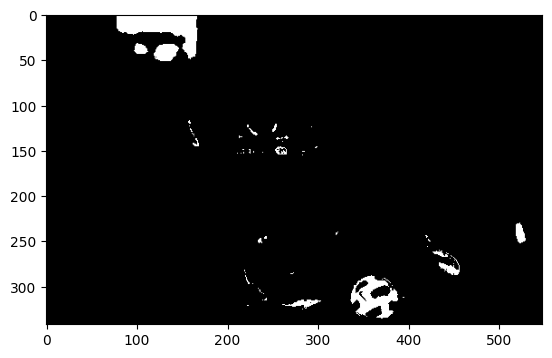

In [10]:
#| fig-align: center
plt.imshow(mask1, cmap='gray');

In [11]:
mask1[:, :330] = 0
mask1[:, 405:] = 0

The next section of code identifies contours around the ball region, computes
the convex hull around these points and then draws this on the original image.

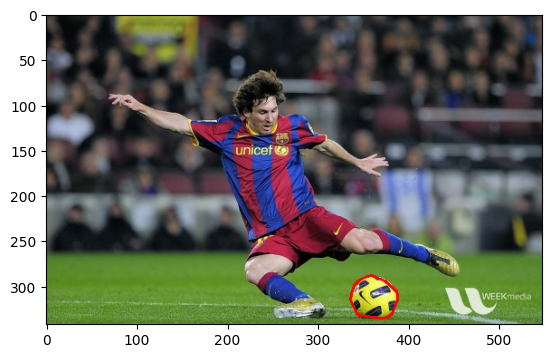

In [12]:
#| fig-align: center
#im2, contours= cv2.findContours(mask1, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

contours, _ = cv2.findContours(mask1, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

largest_contour = max(contours, key=cv2.contourArea)
hull = cv2.convexHull(largest_contour)
cv2.drawContours(messi, [hull], -1, (0, 0, 255), thickness=2)

plt.imshow(cv2.cvtColor(messi, cv2.COLOR_BGR2RGB));

## Modifying Perspective of Images

There are situations where we need to transform the perspective of an image, in
order to identify objects better, or to perform OCR better. To do so, we need
to provide a map of four points from the original image (in the same plane),
and the corresponding four points in the transformed image. Here are a couple
of examples.

::: {#exm-sudoku-1 style="background-color: #D5D1D164; padding: 20px"}
### Example 1: Sudoku
\index{Sudoku!Perspective}

Here is an example of transforming the perspective.

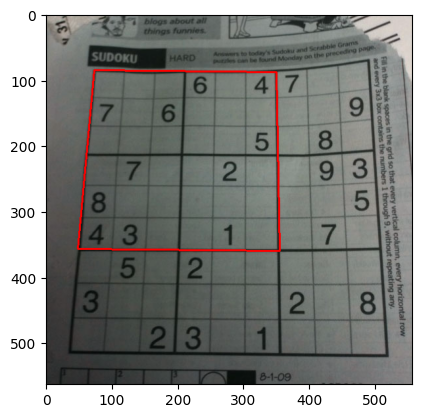

In [13]:
#| fig-align: center
sudoku = cv2.imread('data/sudoku.png')
rows,cols,ch = sudoku.shape

pts1 = np.float32([[73,85], [350, 88], [355, 360], [48, 357]])

pts = np.array(pts1, np.int32)
img2 = cv2.polylines(sudoku, [pts], True, (255, 0, 0), 2 )
plt.imshow(img2);

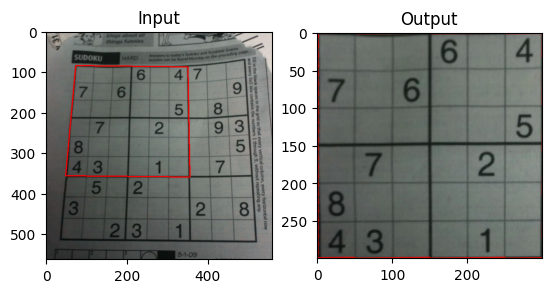

In [14]:
#| fig-align: center
pts2 = np.float32([[0,0],[300,0],[300,300],[0,300]])
M = cv2.getPerspectiveTransform(pts1,pts2)
dst = cv2.warpPerspective(sudoku ,M,(300,300))
 
plt.subplot(121),plt.imshow(sudoku),plt.title('Input')
plt.subplot(122),plt.imshow(dst),plt.title('Output');

:::

::: {#exm-football-1 style="background-color: #D5D1D164; padding: 20px"}
### Example 2: Football
\index{Football!Perspective}

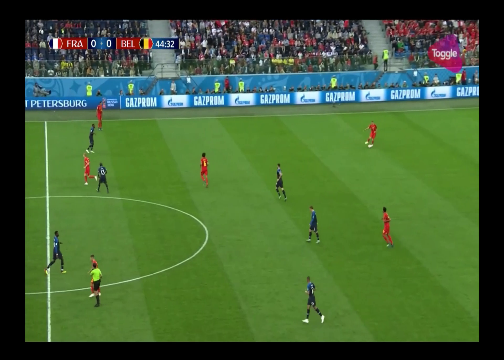

In [15]:
Image('data/football1.png')

In [16]:
football1 = cv2.imread('data/football1.png')
pts1 = np.float32([[45,121],[48,238],[206,230], [155,118]])
pts2 = np.float32([[45,100], [45,220], [77,220], [77,100]])

M = cv2.getPerspectiveTransform(pts1,pts2)
dst = cv2.warpPerspective(football1, M, (504, 360))

pts = np.array([[45,121],[48,238],[206,230], [155,119]], np.int32)
pts = pts.reshape((-1,1,2))
img2 = cv2.polylines(football1, [pts], True, (255, 0, 0), 1 )

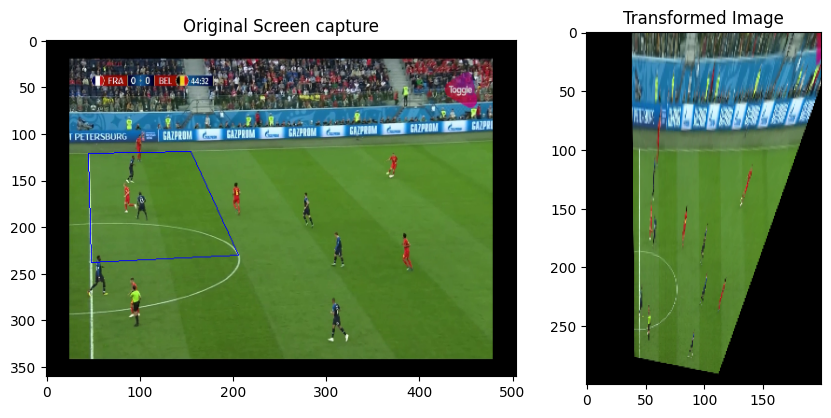

In [17]:
#| fig-align: center
fig = plt.figure(figsize=(10, 5)) 
gs = fig.add_gridspec(1, 2, width_ratios=[2, 1]) 

# First subplot
ax1 = fig.add_subplot(gs[0])
ax1.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
ax1.set_title('Original Screen capture')

# Second subplot
ax2 = fig.add_subplot(gs[1])
ax2.imshow(cv2.cvtColor(dst[:300, :200], cv2.COLOR_BGR2RGB))
ax2.set_title('Transformed Image');

:::

## Computer Vision Tasks

Just as we observed there are numerous NLP tasks, the field of computer vision has made great strides in several tasks. Among them are:

1. Object detection
2. Object classification
3. Object tracking
4. Face detection
5. Pose estimation
6. QR/Bar code detection
7. Text detection/extraction

Almost all the models that perform well in the above tasks are deep learning
models. In the next few sections, we are going to practice running/configuring
some of the above models. Although these models are already trained, it is a
little tricky to find the resources and parameters to get them up and running.

There are three repositories of interest:

1. `opencv`: This contains example images and videos, and configuration files
   for several models.
2. `opencv_extra`: This contains more configuration details for the models,
   along with routines to download model weights.
3. `opencv_zoo`: This contains a smaller range of models, along with the model
   weights.

For our course, we have pre-downloaded some models for us to play around with,
`models`. However, the general approach to start working on one of these models
is as follows:

1. Download the model weights using `opencv_extra/testdata/dnn/download_models.py`
2. Figure out what other configuration files/parameters are needed for this
   model. Sometimes information is in `opencv/samples/dnn/models.yml`. At other
   times, you may need to figure it out from the github repository for the
   particular model.
3. Test it out using one of the sample scripts from `opencv/samples/dnn/*.py`
4. Once you have that working, inspect the script to obtain details on how to
   call the model programmatically, and proceed from there.

## References

### Opencv documentation

1. [Python tutorials](https://docs.opencv.org/4.10.0/d6/d00/tutorial_py_root.html)
2. [Changing colour spaces](https://docs.opencv.org/4.10.0/df/d9d/tutorial_py_colorspaces.html)
3. [Background subtraction](https://docs.opencv.org/3.4/d1/dc5/tutorial_background_subtraction.html)
4. [Opencv bootcamp](https://courses.opencv.org/courses/course-v1:OpenCV+Bootcamp+CV0/about): This is a very useful course on opencv techniques. It will also provide you several more notebooks with template code for object tracking, etc.

### Books

A very comprehensive book on vision techniques is by @szeliski2022computer. An online 
version can be found here: [Computer Vision: Applications and Algorithms](https://szeliski.org/Book/)

### Github repositories

1. [opencv](https://github.com/opencv/opencv)
2. [opencv-extra](https://github.com/opencv/opencv_extra)
3. [opencv model zoo](https://github.com/opencv/opencv_zoo)